# Volume Consolidation & Analysis

This notebook consolidates all plane results and provides comprehensive visualizations of mask quality and trace analysis.

In [24]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.gridspec as gridspec
import lbm_suite2p_python as lsp
from scipy import stats as scipy_stats

# Set style
plt.style.use('dark_background')
sns.set_palette("husl")
%matplotlib inline

## 1. Consolidate Volume

In [9]:
# Path to your suite2p directory
suite2p_path = r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p"
suite2p_path = Path(suite2p_path)

# Consolidate
merged_path = lsp.consolidate_volume(
    suite2p_path=suite2p_path,
    merged_dir="merged",
    overwrite=True
)

Found 14 planes to consolidate
  Processing plane 1: plane01_stitched
  Processing plane 2: plane02_stitched
  Processing plane 3: plane03_stitched
  Processing plane 4: plane04_stitched
  Processing plane 5: plane05_stitched
  Processing plane 6: plane06_stitched
  Processing plane 7: plane07_stitched
  Processing plane 8: plane08_stitched
  Processing plane 9: plane09_stitched
  Processing plane 10: plane10_stitched
  Processing plane 11: plane11_stitched
  Processing plane 12: plane12_stitched
  Processing plane 13: plane13_stitched
  Processing plane 14: plane14_stitched

Saving consolidated results to \\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p\merged
  Saved stat.npy: 13459 total ROIs
  Saved iscell.npy: 6507 accepted, 6952 rejected
  Saved F.npy: shape (13459, 58825)
  Saved Fneu.npy: shape (13459, 58825)
  Saved spks.npy: shape (13459, 58825)
  Saved ops.npy: 14 planes consolidated

Consolidation complete!
Total ROIs: 13459
Planes: 14


## 2. Load Consolidated Data

In [10]:
# Load all data
ops = np.load(merged_path / "ops.npy", allow_pickle=True).item()
stat = np.load(merged_path / "stat.npy", allow_pickle=True)
iscell = np.load(merged_path / "iscell.npy")
F = np.load(merged_path / "F.npy")
Fneu = np.load(merged_path / "Fneu.npy")

# Get accepted cells
accepted_mask = iscell[:, 0] == 1
stat_accepted = stat[accepted_mask]
F_accepted = F[accepted_mask]
Fneu_accepted = Fneu[accepted_mask]

print(f"Total ROIs: {len(stat)}")
print(f"Accepted: {accepted_mask.sum()}")
print(f"Rejected: {(~accepted_mask).sum()}")
print(f"Planes: {ops['nplanes']}")

Total ROIs: 13459
Accepted: 6507
Rejected: 6952
Planes: 14


## 3. Multi-Plane Mask Visualization

Show masks from all planes in a single figure with grid layout.

KeyboardInterrupt: 

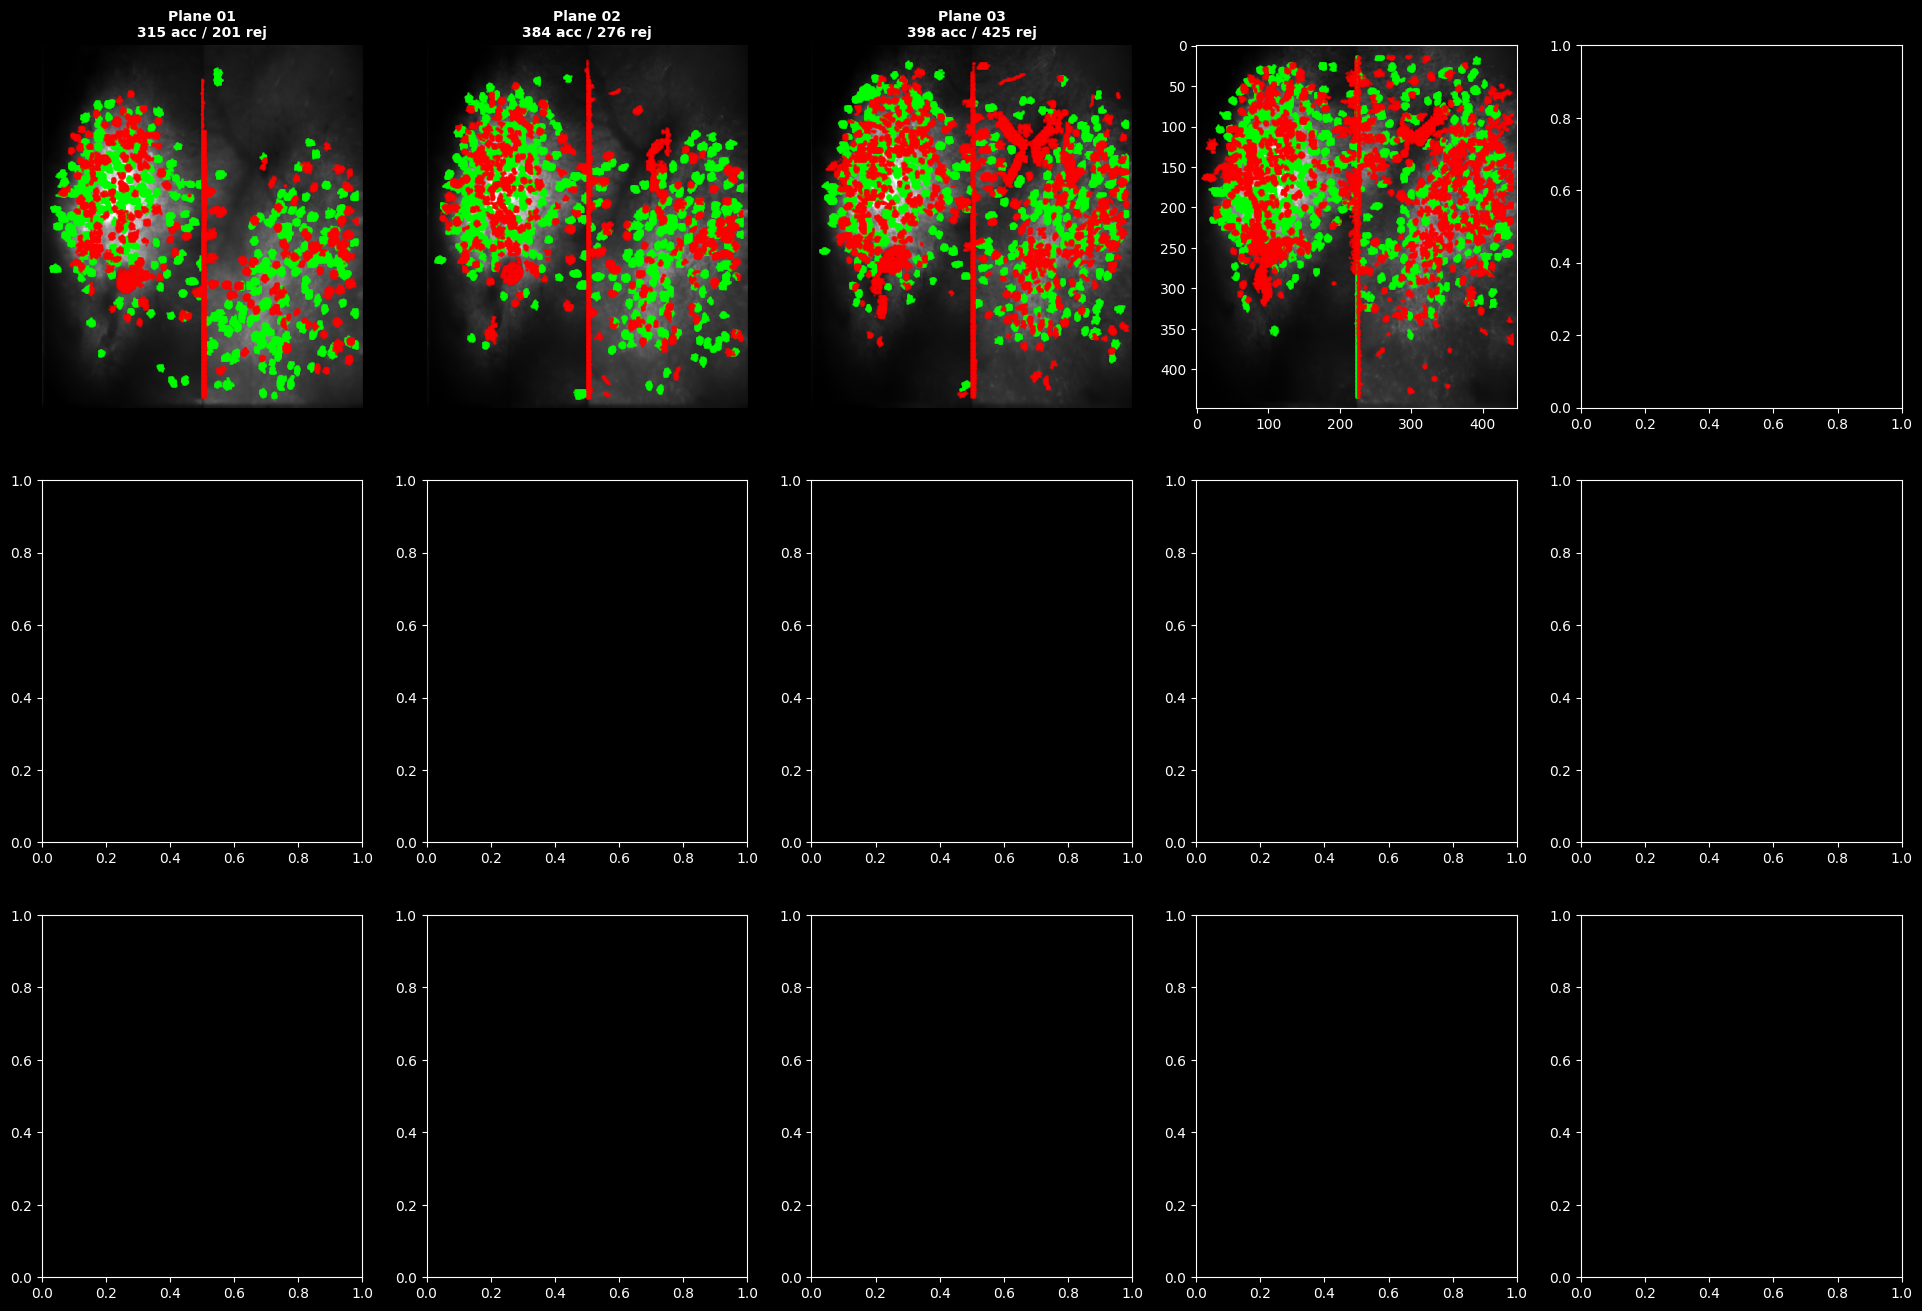

In [25]:
def plot_multiplane_masks(suite2p_path, stat, iscell, nrows=3, ncols=5, figsize=(24, 16)):
    """
    Plot masks from all planes in a grid layout.
    """
    plane_dirs = sorted(suite2p_path.glob("plane*_stitched"))
    nplanes = len(plane_dirs)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor='black')
    axes = axes.flatten()

    for idx, plane_dir in enumerate(plane_dirs):
        if idx >= len(axes):
            break

        ax = axes[idx]
        plane_num = int(''.join(filter(str.isdigit, plane_dir.name)))

        # Load plane ops for image dimensions
        plane_ops = np.load(plane_dir / "ops.npy", allow_pickle=True).item()

        # Get mean image
        if 'meanImg' in plane_ops:
            img = plane_ops['meanImg']
        elif 'meanImgE' in plane_ops:
            img = plane_ops['meanImgE']
        else:
            img = np.zeros((plane_ops['Ly'], plane_ops['Lx']))

        # Show background image
        ax.imshow(img, cmap='gray', aspect='auto', vmin=np.percentile(img, 1), vmax=np.percentile(img, 99))

        # Get ROIs for this plane
        plane_mask = np.array([s['iplane'] == plane_num for s in stat])
        plane_stat = stat[plane_mask]
        plane_iscell = iscell[plane_mask]

        # Draw accepted cells in green
        accepted_idx = plane_iscell[:, 0] == 1
        for s in plane_stat[accepted_idx]:
            ypix = s['ypix']
            xpix = s['xpix']
            ax.scatter(xpix, ypix, c='lime', s=1, alpha=0.6)

        # Draw rejected cells in red
        rejected_idx = plane_iscell[:, 0] == 0
        for s in plane_stat[rejected_idx]:
            ypix = s['ypix']
            xpix = s['xpix']
            ax.scatter(xpix, ypix, c='red', s=1, alpha=0.4)

        n_accepted = accepted_idx.sum()
        n_rejected = rejected_idx.sum()

        ax.set_title(f'Plane {plane_num:02d}\n{n_accepted} acc / {n_rejected} rej',
                     fontsize=10, color='white', fontweight='bold')
        ax.axis('off')

    # Hide extra subplots
    for idx in range(nplanes, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    return fig

# Create visualization
fig = plot_multiplane_masks(suite2p_path, stat, iscell)
plt.savefig(merged_path / 'all_planes_masks.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## 4. ROI Quality Metrics Across Planes

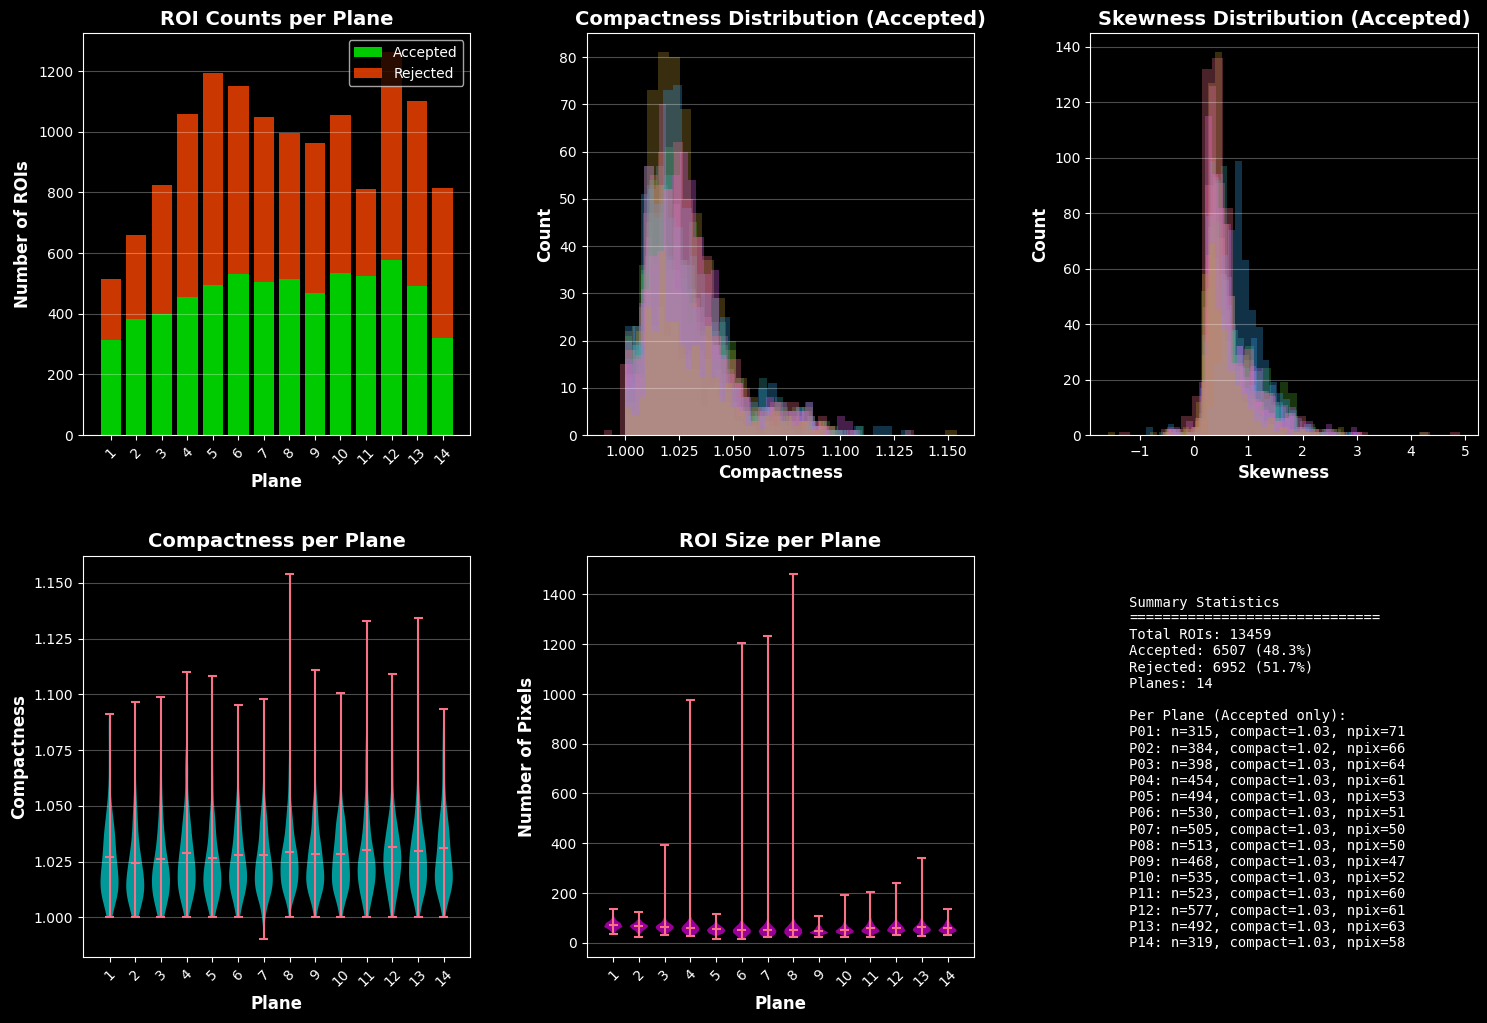

In [12]:
def plot_plane_quality_metrics(stat, iscell, figsize=(18, 12)):
    """
    Plot quality metrics for each plane: counts, compactness, skewness, npix.
    """
    # Extract plane numbers
    plane_nums = np.array([s['iplane'] for s in stat])
    unique_planes = np.unique(plane_nums)

    # Extract metrics
    compactness = np.array([s.get('compact', np.nan) for s in stat])
    skewness = np.array([s.get('skew', np.nan) for s in stat])
    npix = np.array([s['npix'] for s in stat])
    accepted = iscell[:, 0] == 1

    fig = plt.figure(figsize=figsize, facecolor='black')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

    # 1. ROI counts per plane
    ax1 = fig.add_subplot(gs[0, 0])
    counts_accepted = [np.sum((plane_nums == p) & accepted) for p in unique_planes]
    counts_rejected = [np.sum((plane_nums == p) & ~accepted) for p in unique_planes]

    x = np.arange(len(unique_planes))
    ax1.bar(x, counts_accepted, label='Accepted', color='lime', alpha=0.8)
    ax1.bar(x, counts_rejected, bottom=counts_accepted, label='Rejected', color='orangered', alpha=0.8)
    ax1.set_xlabel('Plane', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Number of ROIs', fontweight='bold', fontsize=12)
    ax1.set_title('ROI Counts per Plane', fontweight='bold', fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'{p}' for p in unique_planes], rotation=45)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # 2. Compactness distribution
    ax2 = fig.add_subplot(gs[0, 1])
    for p in unique_planes:
        plane_mask = (plane_nums == p) & accepted & ~np.isnan(compactness)
        if plane_mask.sum() > 0:
            ax2.hist(compactness[plane_mask], bins=30, alpha=0.3, label=f'P{p}')
    ax2.set_xlabel('Compactness', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Count', fontweight='bold', fontsize=12)
    ax2.set_title('Compactness Distribution (Accepted)', fontweight='bold', fontsize=14)
    ax2.grid(axis='y', alpha=0.3)

    # 3. Skewness distribution
    ax3 = fig.add_subplot(gs[0, 2])
    for p in unique_planes:
        plane_mask = (plane_nums == p) & accepted & ~np.isnan(skewness)
        if plane_mask.sum() > 0:
            ax3.hist(skewness[plane_mask], bins=30, alpha=0.3, label=f'P{p}')
    ax3.set_xlabel('Skewness', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Count', fontweight='bold', fontsize=12)
    ax3.set_title('Skewness Distribution (Accepted)', fontweight='bold', fontsize=14)
    ax3.grid(axis='y', alpha=0.3)

    # 4. Mean metrics per plane (violin plot)
    ax4 = fig.add_subplot(gs[1, 0])
    data_compact = [compactness[(plane_nums == p) & accepted & ~np.isnan(compactness)] for p in unique_planes]
    parts = ax4.violinplot(data_compact, positions=range(len(unique_planes)), widths=0.7, showmeans=True)
    for pc in parts['bodies']:
        pc.set_facecolor('cyan')
        pc.set_alpha(0.6)
    ax4.set_xlabel('Plane', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Compactness', fontweight='bold', fontsize=12)
    ax4.set_title('Compactness per Plane', fontweight='bold', fontsize=14)
    ax4.set_xticks(range(len(unique_planes)))
    ax4.set_xticklabels([f'{p}' for p in unique_planes], rotation=45)
    ax4.grid(axis='y', alpha=0.3)

    # 5. Pixel count distribution
    ax5 = fig.add_subplot(gs[1, 1])
    data_npix = [npix[(plane_nums == p) & accepted] for p in unique_planes]
    parts = ax5.violinplot(data_npix, positions=range(len(unique_planes)), widths=0.7, showmeans=True)
    for pc in parts['bodies']:
        pc.set_facecolor('magenta')
        pc.set_alpha(0.6)
    ax5.set_xlabel('Plane', fontweight='bold', fontsize=12)
    ax5.set_ylabel('Number of Pixels', fontweight='bold', fontsize=12)
    ax5.set_title('ROI Size per Plane', fontweight='bold', fontsize=14)
    ax5.set_xticks(range(len(unique_planes)))
    ax5.set_xticklabels([f'{p}' for p in unique_planes], rotation=45)
    ax5.grid(axis='y', alpha=0.3)

    # 6. Summary statistics table
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')

    summary_text = "Summary Statistics\n" + "="*30 + "\n"
    summary_text += f"Total ROIs: {len(stat)}\n"
    summary_text += f"Accepted: {accepted.sum()} ({100*accepted.sum()/len(stat):.1f}%)\n"
    summary_text += f"Rejected: {(~accepted).sum()} ({100*(~accepted).sum()/len(stat):.1f}%)\n"
    summary_text += f"Planes: {len(unique_planes)}\n\n"
    summary_text += "Per Plane (Accepted only):\n"
    for p in unique_planes:
        plane_mask = (plane_nums == p) & accepted
        n = plane_mask.sum()
        mean_compact = np.nanmean(compactness[plane_mask])
        mean_npix = np.mean(npix[plane_mask])
        summary_text += f"P{p:02d}: n={n:3d}, compact={mean_compact:.2f}, npix={mean_npix:.0f}\n"

    ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes,
             fontsize=10, verticalalignment='top', family='monospace',
             color='white')

    return fig

# Create visualization
fig = plot_plane_quality_metrics(stat, iscell)
plt.savefig(merged_path / 'plane_quality_metrics.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## 5. Trace Analysis - Comprehensive Overview

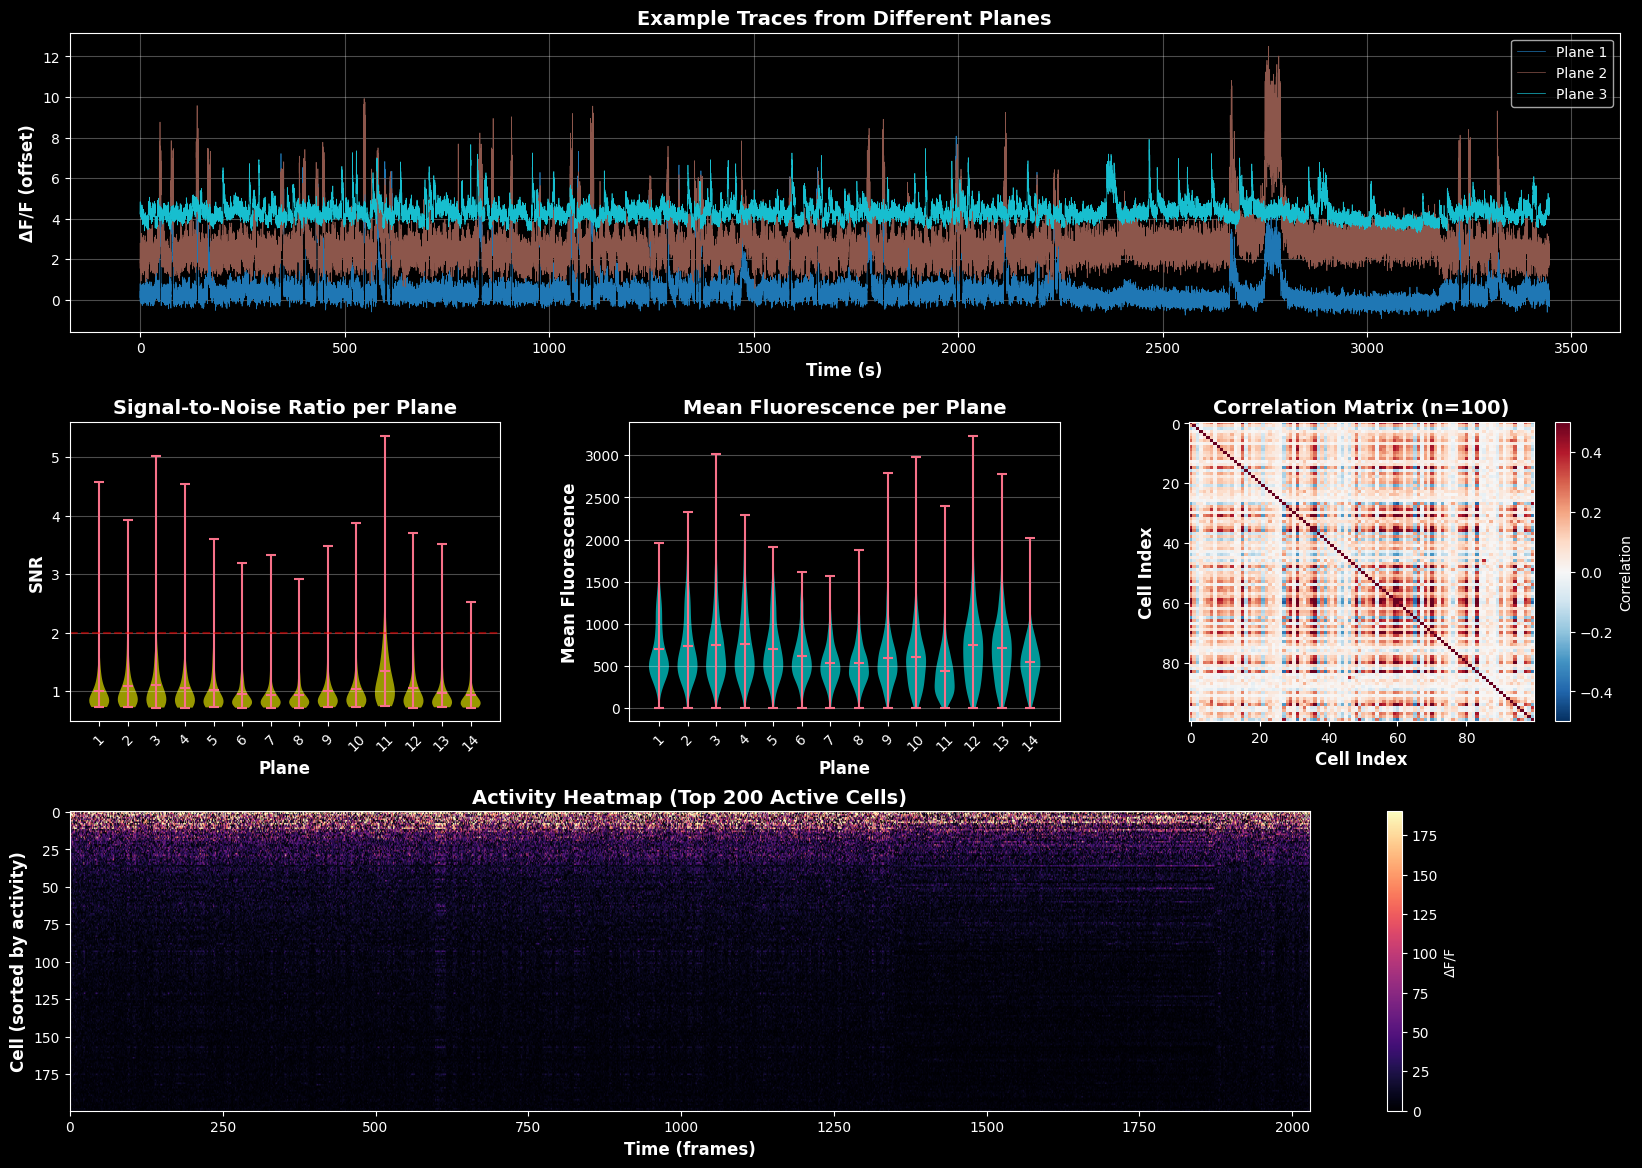

In [13]:
def plot_trace_analysis(F, Fneu, stat, iscell, ops, figsize=(20, 14)):
    """
    Comprehensive trace analysis: SNR, correlation, activity patterns.
    """
    accepted = iscell[:, 0] == 1
    F_acc = F[accepted]
    Fneu_acc = Fneu[accepted]
    stat_acc = stat[accepted]
    plane_nums = np.array([s['iplane'] for s in stat_acc])

    # Compute dF/F
    F_corrected = F_acc - 0.7 * Fneu_acc  # Suite2p default neucoeff
    baseline = np.percentile(F_corrected, 20, axis=1, keepdims=True)
    dff = (F_corrected - baseline) / (baseline + 1e-6)

    # Compute SNR
    signal = np.std(dff, axis=1)
    noise = np.median(np.abs(np.diff(dff, axis=1)), axis=1) / 0.6745  # MAD estimator
    snr = signal / (noise + 1e-6)

    fig = plt.figure(figsize=figsize, facecolor='black')
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

    # 1. Example traces from different planes
    ax1 = fig.add_subplot(gs[0, :])
    unique_planes = np.unique(plane_nums)
    n_examples = min(3, len(unique_planes))
    colors = plt.cm.tab10(np.linspace(0, 1, n_examples))

    offset = 0
    for i, p in enumerate(unique_planes[:n_examples]):
        plane_mask = plane_nums == p
        if plane_mask.sum() > 0:
            idx = np.where(plane_mask)[0][0]  # First cell from this plane
            trace = dff[idx]
            time = np.arange(len(trace)) / ops.get('fs', 30)  # Convert to seconds
            ax1.plot(time, trace + offset, color=colors[i], linewidth=0.5, label=f'Plane {p}')
            offset += 2

    ax1.set_xlabel('Time (s)', fontweight='bold', fontsize=12)
    ax1.set_ylabel('ΔF/F (offset)', fontweight='bold', fontsize=12)
    ax1.set_title('Example Traces from Different Planes', fontweight='bold', fontsize=14)
    ax1.legend(loc='upper right')
    ax1.grid(alpha=0.3)

    # 2. SNR distribution per plane
    ax2 = fig.add_subplot(gs[1, 0])
    snr_by_plane = [snr[plane_nums == p] for p in unique_planes]
    parts = ax2.violinplot(snr_by_plane, positions=range(len(unique_planes)), widths=0.7, showmeans=True)
    for pc in parts['bodies']:
        pc.set_facecolor('yellow')
        pc.set_alpha(0.6)
    ax2.set_xlabel('Plane', fontweight='bold', fontsize=12)
    ax2.set_ylabel('SNR', fontweight='bold', fontsize=12)
    ax2.set_title('Signal-to-Noise Ratio per Plane', fontweight='bold', fontsize=14)
    ax2.set_xticks(range(len(unique_planes)))
    ax2.set_xticklabels([f'{p}' for p in unique_planes], rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    ax2.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='SNR=2')

    # 3. Mean fluorescence per plane
    ax3 = fig.add_subplot(gs[1, 1])
    mean_F = np.mean(F_acc, axis=1)
    mean_F_by_plane = [mean_F[plane_nums == p] for p in unique_planes]
    parts = ax3.violinplot(mean_F_by_plane, positions=range(len(unique_planes)), widths=0.7, showmeans=True)
    for pc in parts['bodies']:
        pc.set_facecolor('cyan')
        pc.set_alpha(0.6)
    ax3.set_xlabel('Plane', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Mean Fluorescence', fontweight='bold', fontsize=12)
    ax3.set_title('Mean Fluorescence per Plane', fontweight='bold', fontsize=14)
    ax3.set_xticks(range(len(unique_planes)))
    ax3.set_xticklabels([f'{p}' for p in unique_planes], rotation=45)
    ax3.grid(axis='y', alpha=0.3)

    # 4. Activity correlation matrix (sample)
    ax4 = fig.add_subplot(gs[1, 2])
    n_sample = min(100, len(dff))
    sample_idx = np.random.choice(len(dff), n_sample, replace=False)
    corr_matrix = np.corrcoef(dff[sample_idx])
    im = ax4.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax4.set_xlabel('Cell Index', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Cell Index', fontweight='bold', fontsize=12)
    ax4.set_title(f'Correlation Matrix (n={n_sample})', fontweight='bold', fontsize=14)
    plt.colorbar(im, ax=ax4, label='Correlation')

    # 5. Activity heatmap (sorted by activity)
    ax5 = fig.add_subplot(gs[2, :])
    activity = np.sum(dff > 1, axis=1)  # Number of peaks > 1 std
    sort_idx = np.argsort(activity)[::-1][:200]  # Top 200 most active

    # Downsample time for visualization
    downsample = max(1, dff.shape[1] // 2000)
    dff_plot = dff[sort_idx, ::downsample]

    im = ax5.imshow(dff_plot, aspect='auto', cmap='magma', vmin=0, vmax=np.percentile(dff_plot, 99))
    ax5.set_xlabel('Time (frames)', fontweight='bold', fontsize=12)
    ax5.set_ylabel('Cell (sorted by activity)', fontweight='bold', fontsize=12)
    ax5.set_title('Activity Heatmap (Top 200 Active Cells)', fontweight='bold', fontsize=14)
    plt.colorbar(im, ax=ax5, label='ΔF/F')

    return fig, {'snr': snr, 'dff': dff, 'mean_F': mean_F}

# Create visualization
fig, trace_metrics = plot_trace_analysis(F_accepted, Fneu_accepted, stat_accepted,
                                         iscell[accepted_mask], ops)
plt.savefig(merged_path / 'trace_analysis.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## 6. Statistical Summary Table

In [14]:
def create_summary_table(stat, iscell, trace_metrics):
    """
    Create a comprehensive summary table.
    """
    accepted = iscell[:, 0] == 1
    plane_nums = np.array([s['iplane'] for s in stat[accepted]])
    unique_planes = np.unique(plane_nums)

    snr = trace_metrics['snr']
    mean_F = trace_metrics['mean_F']

    summary_data = []
    for p in unique_planes:
        plane_mask = plane_nums == p
        n = plane_mask.sum()

        summary_data.append({
            'Plane': p,
            'N_ROIs': n,
            'Mean_SNR': f"{np.mean(snr[plane_mask]):.2f}",
            'Median_SNR': f"{np.median(snr[plane_mask]):.2f}",
            'Mean_F': f"{np.mean(mean_F[plane_mask]):.0f}",
            'High_SNR_%': f"{100*np.sum(snr[plane_mask] > 2)/n:.1f}",
        })

    import pandas as pd
    df = pd.DataFrame(summary_data)

    # Add totals row
    totals = {
        'Plane': 'ALL',
        'N_ROIs': len(snr),
        'Mean_SNR': f"{np.mean(snr):.2f}",
        'Median_SNR': f"{np.median(snr):.2f}",
        'Mean_F': f"{np.mean(mean_F):.0f}",
        'High_SNR_%': f"{100*np.sum(snr > 2)/len(snr):.1f}",
    }
    df = pd.concat([df, pd.DataFrame([totals])], ignore_index=True)

    return df

# Create and display table
summary_df = create_summary_table(stat, iscell, trace_metrics)
print("\n" + "="*80)
print("CONSOLIDATED VOLUME SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Save table
summary_df.to_csv(merged_path / 'summary_table.csv', index=False)
print(f"\nSummary table saved to: {merged_path / 'summary_table.csv'}")


CONSOLIDATED VOLUME SUMMARY
Plane  N_ROIs Mean_SNR Median_SNR Mean_F High_SNR_%
    1     315     1.00       0.87    694        2.5
    2     384     1.09       0.91    734        4.4
    3     398     1.11       0.93    746        5.8
    4     454     1.06       0.89    763        5.5
    5     494     1.02       0.86    696        3.8
    6     530     0.95       0.86    621        1.3
    7     505     0.93       0.84    532        2.0
    8     513     0.94       0.84    528        2.7
    9     468     1.00       0.87    593        3.6
   10     535     1.04       0.89    599        4.9
   11     523     1.35       1.13    441       11.9
   12     577     1.05       0.87    741        5.7
   13     492     0.98       0.84    711        3.3
   14     319     0.93       0.82    547        1.3
  ALL    6507     1.04       0.87    636        4.3

Summary table saved to: \\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p\merged\summary_table.csv


## 7. Save All Visualizations Summary

In [ ]:
print("\n" + "="*80)
print("VISUALIZATION FILES SAVED")
print("="*80)
viz_files = [
    'all_planes_masks.png',
    'plane_quality_metrics.png',
    'trace_analysis.png',
    'summary_table.csv'
]

for f in viz_files:
    fpath = merged_path / f
    if fpath.exists():
        size_mb = fpath.stat().st_size / (1024 * 1024)
        print(f"✓ {f:35s} {size_mb:6.2f} MB")
    else:
        print(f"✗ {f:35s} NOT FOUND")

print("="*80)
print(f"All visualizations saved to: {merged_path}")

In [33]:
import napari

In [ ]:
import numpy as np
import zarr
from pathlib import Path
from typing import List, Tuple
import napari
from suite2p.io.binary import BinaryFile


class LazyVolumeLoader:
    """
    Lazy loader for Suite2p volume data using zarr.

    Creates a virtual zarr array that reads from individual plane data.bin files
    without copying all data into memory or creating a new file.
    """

    def __init__(self, suite2p_path: Path, use_registered: bool = True):
        """
        Initialize lazy volume loader.

        Parameters
        ----------
        suite2p_path : Path
            Path to suite2p directory containing plane folders
        use_registered : bool
            Whether to use data.bin (registered) or data_raw.bin (raw)
        """
        self.suite2p_path = Path(suite2p_path)
        self.use_registered = use_registered

        # Find all plane directories
        self.plane_dirs = sorted(self.suite2p_path.glob("plane*_stitched"))
        if not self.plane_dirs:
            raise ValueError(f"No plane directories found in {suite2p_path}")

        print(f"Found {len(self.plane_dirs)} planes")

        # Get dimensions from first plane
        first_ops = np.load(self.plane_dirs[0] / "ops.npy", allow_pickle=True).item()
        self.Ly = first_ops['Ly']
        self.Lx = first_ops['Lx']
        self.nframes = first_ops['nframes']

        # Check if we should use cropped dimensions
        if 'yrange' in first_ops and 'xrange' in first_ops:
            yrange = first_ops['yrange']
            xrange = first_ops['xrange']
            self.Ly_crop = yrange[1] - yrange[0]
            self.Lx_crop = xrange[1] - xrange[0]
            self.y_offset = yrange[0]
            self.x_offset = xrange[0]
            self.use_crop = True
            print(f"Using cropped dimensions: {self.Ly_crop}x{self.Lx_crop} (from {self.Ly}x{self.Lx})")
        else:
            self.Ly_crop = self.Ly
            self.Lx_crop = self.Lx
            self.y_offset = 0
            self.x_offset = 0
            self.use_crop = False

        self.nplanes = len(self.plane_dirs)

        print(f"Volume dimensions: {self.nplanes} x {self.Ly_crop} x {self.Lx_crop}")
        print(f"Time points: {self.nframes}")

    def create_zarr_volume(self, store_path: Path = None, time_downsample: int = 10,
                          force_recreate: bool = False) -> zarr.Array:
        """
        Create a zarr array that lazily loads data from plane binaries.
        If the zarr volume already exists, it will be loaded instead of recreated.

        Parameters
        ----------
        store_path : Path, optional
            Path to store zarr array. If None, uses temporary directory.
        time_downsample : int
            Temporal downsampling factor to reduce memory usage
        force_recreate : bool
            If True, force recreation even if zarr volume exists

        Returns
        -------
        zarr_volume : zarr.Array
            Virtual volume array (Z, Y, X)
        """
        if store_path is None:
            store_path = self.suite2p_path / "temp_volume.zarr"

        store_path = Path(store_path)

        # Check if zarr volume already exists
        if store_path.exists() and not force_recreate:
            print(f"Loading existing zarr volume from {store_path}...")
            try:
                root = zarr.open(str(store_path), mode='r')

                # Verify the volume has expected datasets
                if 'mean_image' in root and 'max_projection' in root:
                    mean_shape = root['mean_image'].shape
                    max_shape = root['max_projection'].shape

                    # Verify dimensions match
                    expected_shape = (self.nplanes, self.Ly_crop, self.Lx_crop)
                    if mean_shape == expected_shape and max_shape == expected_shape:
                        print(f"  Successfully loaded existing volume with shape {mean_shape}")
                        return root
                    else:
                        print(f"  WARNING: Existing volume has wrong shape {mean_shape}, expected {expected_shape}")
                        print(f"  Recreating zarr volume...")
                else:
                    print(f"  WARNING: Existing volume missing expected datasets")
                    print(f"  Recreating zarr volume...")
            except Exception as e:
                print(f"  WARNING: Could not load existing volume: {e}")
                print(f"  Recreating zarr volume...")

        # Calculate downsampled time dimension
        n_timepoints = self.nframes // time_downsample

        # Create zarr array for mean image (one per plane)
        print(f"Creating zarr volume at {store_path}...")

        # Remove existing store
        if store_path.exists():
            import shutil
            shutil.rmtree(store_path)

        # Create store
        root = zarr.group(store=str(store_path), overwrite=True)

        # Create mean image volume (Z, Y, X)
        mean_volume = root.create_dataset(
            'mean_image',
            shape=(self.nplanes, self.Ly_crop, self.Lx_crop),
            chunks=(1, self.Ly_crop, self.Lx_crop),
            dtype='float32'
        )

        # Create max projection volume
        max_volume = root.create_dataset(
            'max_projection',
            shape=(self.nplanes, self.Ly_crop, self.Lx_crop),
            chunks=(1, self.Ly_crop, self.Lx_crop),
            dtype='float32'
        )

        # Load each plane
        for z, plane_dir in enumerate(self.plane_dirs):
            plane_num = int(''.join(filter(str.isdigit, plane_dir.name)))
            print(f"  Loading plane {plane_num} ({z+1}/{self.nplanes})...")

            # Get binary file path
            bin_file = plane_dir / ("data.bin" if self.use_registered else "data_raw.bin")

            if not bin_file.exists():
                print(f"    WARNING: {bin_file.name} not found, using zeros")
                mean_volume[z] = np.zeros((self.Ly_crop, self.Lx_crop), dtype='float32')
                max_volume[z] = np.zeros((self.Ly_crop, self.Lx_crop), dtype='float32')
                continue

            # Load ops to get actual dimensions
            ops = np.load(plane_dir / "ops.npy", allow_pickle=True).item()

            # Open binary file
            with BinaryFile(Ly=self.Ly, Lx=self.Lx, filename=str(bin_file)) as f:
                # Sample frames for mean/max
                n_samples = min(1000, f.n_frames)
                sample_indices = np.linspace(0, f.n_frames-1, n_samples, dtype=int)

                # Read sampled data
                data_sample = f.file[sample_indices].astype('float32')

                # Crop if needed
                if self.use_crop:
                    data_sample = data_sample[:, self.y_offset:self.y_offset+self.Ly_crop,
                                             self.x_offset:self.x_offset+self.Lx_crop]

                # Compute statistics
                mean_img = np.mean(data_sample, axis=0)
                max_img = np.max(data_sample, axis=0)

                # Store in zarr
                mean_volume[z] = mean_img
                max_volume[z] = max_img

        print(f"Zarr volume created at {store_path}")
        return root

    def load_masks_3d(self, stat: np.ndarray, iscell: np.ndarray = None,
                      accepted_only: bool = True) -> Tuple[np.ndarray, np.ndarray]:
        """
        Convert 2D masks to 3D volume coordinates.

        Parameters
        ----------
        stat : np.ndarray
            Suite2p stat array with 'iplane' field
        iscell : np.ndarray, optional
            iscell array for filtering
        accepted_only : bool
            Whether to only include accepted cells

        Returns
        -------
        coords : np.ndarray
            Nx3 array of (z, y, x) coordinates
        labels : np.ndarray
            Label for each coordinate (ROI index)
        """
        coords = []
        labels = []

        for roi_idx, s in enumerate(stat):
            # Filter by iscell
            if accepted_only and iscell is not None:
                if iscell[roi_idx, 0] == 0:
                    continue

            # Get plane (z coordinate) - convert from 1-based to 0-based
            z = s.get('iplane', 1) - 1

            # Skip if z index is out of bounds
            if z < 0 or z >= self.nplanes:
                continue

            # Get y, x coordinates
            ypix = s['ypix']
            xpix = s['xpix']

            # Create 3D coordinates
            n_pixels = len(ypix)
            z_coords = np.full(n_pixels, z)

            # Stack coordinates
            roi_coords = np.column_stack([z_coords, ypix, xpix])
            coords.append(roi_coords)
            labels.extend([roi_idx] * n_pixels)

        coords = np.vstack(coords) if coords else np.zeros((0, 3))
        labels = np.array(labels)

        return coords, labels

    def create_mask_volume(self, stat: np.ndarray, iscell: np.ndarray = None,
                          accepted_only: bool = True) -> np.ndarray:
        """
        Create a 3D mask volume.

        Parameters
        ----------
        stat : np.ndarray
            Suite2p stat array
        iscell : np.ndarray, optional
            iscell array for filtering
        accepted_only : bool
            Whether to only include accepted cells

        Returns
        -------
        mask_volume : np.ndarray
            3D volume with ROI labels (Z, Y, X)
        """
        print("Creating 3D mask volume...")
        mask_volume = np.zeros((self.nplanes, self.Ly_crop, self.Lx_crop), dtype='uint16')

        n_rois = 0
        for roi_idx, s in enumerate(stat):
            # Filter by iscell
            if accepted_only and iscell is not None:
                if iscell[roi_idx, 0] == 0:
                    continue

            # Get plane (convert from 1-based to 0-based indexing)
            z = s.get('iplane', 1) - 1

            # Skip if z index is out of bounds
            if z < 0 or z >= self.nplanes:
                continue

            # Get coordinates
            ypix = s['ypix']
            xpix = s['xpix']

            # Adjust for crop offset
            if self.use_crop:
                ypix = ypix - self.y_offset
                xpix = xpix - self.x_offset

                # Filter out of bounds pixels
                valid_mask = (ypix >= 0) & (ypix < self.Ly_crop) & (xpix >= 0) & (xpix < self.Lx_crop)
                ypix = ypix[valid_mask]
                xpix = xpix[valid_mask]

            if len(ypix) > 0:
                # Use roi_idx + 1 as label (0 is background)
                mask_volume[z, ypix, xpix] = roi_idx + 1
                n_rois += 1

        print(f"  Added {n_rois} ROIs to volume")
        return mask_volume


def view_volume_napari(suite2p_path: str | Path, merged_dir: str = "merged",
                      time_downsample: int = 10, use_max_projection: bool = False,
                      force_recreate: bool = False, scale: tuple = None):
    """
    Launch napari viewer with 3D volume and masks.

    Parameters
    ----------
    suite2p_path : str or Path
        Path to suite2p directory
    merged_dir : str
        Name of merged directory with consolidated data
    time_downsample : int
        Temporal downsampling factor
    use_max_projection : bool
        Whether to use max projection instead of mean image
    force_recreate : bool
        If True, force recreation of zarr volume even if it exists
    scale : tuple, optional
        Scale for the volume in (Z, Y, X) format. If None, defaults to (1, 1, 1).
        Example: (15, 2, 2) for 15um z-spacing and 2um xy pixel size
    """
    suite2p_path = Path(suite2p_path)
    merged_path = suite2p_path / merged_dir

    # Set default scale
    if scale is None:
        scale = (1, 1, 1)

    # Load consolidated data
    print("Loading consolidated data...")
    stat = np.load(merged_path / "stat.npy", allow_pickle=True)
    iscell = np.load(merged_path / "iscell.npy")

    print(f"Loaded {len(stat)} ROIs ({(iscell[:, 0] == 1).sum()} accepted)")

    # Create lazy loader
    loader = LazyVolumeLoader(suite2p_path, use_registered=True)

    # Create or load zarr volume
    zarr_root = loader.create_zarr_volume(
        store_path=suite2p_path / "temp_volume.zarr",
        time_downsample=time_downsample,
        force_recreate=force_recreate
    )

    # Get volume data
    if use_max_projection:
        volume_data = zarr_root['max_projection'][:]
        volume_name = "Max Projection"
    else:
        volume_data = zarr_root['mean_image'][:]
        volume_name = "Mean Image"

    print(f"Volume shape: {volume_data.shape}")

    # Create mask volume
    mask_volume = loader.create_mask_volume(stat, iscell, accepted_only=True)

    # Launch napari
    print("\nLaunching napari viewer...")
    viewer = napari.Viewer(ndisplay=3, title="Suite2p Volume Viewer")

    # Add volume layer
    viewer.add_image(
        volume_data,
        name=volume_name,
        colormap='gray',
        blending='translucent',
        opacity=0.5,
        contrast_limits=[np.percentile(volume_data, 1), np.percentile(volume_data, 99)],
        scale=scale
    )

    # Add mask layer with the same scale
    viewer.add_labels(
        mask_volume,
        name='ROI Masks',
        opacity=0.7,
        blending='translucent',
        scale=scale
    )

    # Set camera angle
    viewer.camera.angles = (0, 45, 45)
    viewer.camera.zoom = 2.0

    print("Napari viewer launched!")
    print(f"Volume scale (Z, Y, X): {scale}")
    print("\nControls:")
    print("  - Left click + drag: Rotate")
    print("  - Right click + drag: Pan")
    print("  - Scroll: Zoom")
    print("  - Toggle layers on/off in left panel")

    return viewer

In [35]:
# Launch 3D viewer
# This creates a zarr volume with mean/max projections and displays ROI masks in 3D
viewer = view_volume_napari(
    suite2p_path=suite2p_path,
    merged_dir="merged",
    time_downsample=10,
    use_max_projection=False,  # Set to True to use max projection instead of mean
    scale=(15, 2, 2)  # Z, Y, X scale (15um z-spacing, 2um xy pixel size)
)

# Uncomment the next line to run the napari event loop (blocks execution)
# napari.run()

Loading consolidated data...
Loaded 13459 ROIs (6507 accepted)
Found 14 planes
Using cropped dimensions: 422x434 (from 448x448)
Volume dimensions: 14 x 422 x 434
Time points: 58825
Loading existing zarr volume from \\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p\temp_volume.zarr...
  Successfully loaded existing volume with shape (14, 422, 434)
Volume shape: (14, 422, 434)
Creating 3D mask volume...
  Added 6507 ROIs to volume

Launching napari viewer...
Napari viewer launched!
Volume scale (Z, Y, X): (15, 2, 2)

Controls:
  - Left click + drag: Rotate
  - Right click + drag: Pan
  - Scroll: Zoom
  - Toggle layers on/off in left panel


In [30]:
viewer.scale_bar.visible=True